<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 2: Sequence Models

**University of Maryland, College Park**  
**Summer 2026**  
**Instructor**: Armin Mehrabian  
**Date**: June 10, 2026  


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 1. Probabilistic Language Models



# Probabilistic Language Models  

**Goal:** Use probability to decide which sentence is more natural.  


**Applications**  

- **Machine Translation:**  
  $P(\text{strong rain tomorrow}) > P(\text{big rain tomorrow})$  

- **Spell Checking:**  
  *She wants to eat **desert***  
  - $P(\text{eat dessert}) > P(\text{eat desert})$  

- **Speech Recognition:**  
  $P(\text{recognize speech}) \gg P(\text{wreck a nice beach})$  



# Probabilistic Language Modeling (1/2)  

**Goal:**  
Compute the probability of a sentence or sequence of words:  

$$
P(W) = P(w_1, w_2, w_3, \dots, w_n)
$$  


# Probabilistic Language Modeling (2/2)  

**Related task:**  
Compute the probability of the next word given the history:  

$$
P(w_{t} \mid w_1, w_2, \dots, w_{t-1})
$$  

**Definition:**  
A model that estimates either $P(W)$ or $P(w_t \mid w_1, \dots, w_{t-1})$ is called a **language model (LM)**.  

*Note:* In linguistics the term *grammar* is often used, but in NLP the standard term is **language model**.


# How to Compute $P(W)$  

**Question:** How do we calculate the probability of an entire sentence?  

Example joint probability:  

$$
P(\text{the}, \text{cat}, \text{sat}, \text{on}, \text{the}, \text{mat})
$$  

**Intuition:**  
We rely on the **Chain Rule of Probability** to decompose this joint probability into a sequence of conditional probabilities.


# Reminder: Conditional Probability  

**Definition:**  

$$
P(A \mid B) = \frac{P(A, B)}{P(B)}
$$  

Rearranged:  

$$
P(A, B) = P(A \mid B) \, P(B)
$$  


# Reminder: The Chain Rule  

For multiple variables:  

$$
P(A, B, C, D) = P(A) \, P(B \mid A) \, P(C \mid A, B) \, P(D \mid A, B, C)
$$  

**In general:**  

$$
P(x_1, x_2, \dots, x_n) = \prod_{t=1}^n P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$  

---

**Intuitive Example: Will You Pass This Class?**  

Suppose we want to know: $P(\text{pass class})$  

This depends on multiple factors:  
- Did you attend lectures? $P(\text{attend})$  
- Did you do the homeworks? $P(\text{hw} \mid \text{attend})$  
- Did you understand the material? $P(\text{understand} \mid \text{attend, hw})$  
- Did you pass the exam? $P(\text{pass} \mid \text{attend, hw, understand})$  

Chain rule breaks it down:  

$$
P(\text{attend, hw, understand, pass}) = P(\text{attend}) \cdot P(\text{hw} \mid \text{attend}) \cdot P(\text{understand} \mid \text{attend, hw}) \cdot P(\text{pass} \mid \text{attend, hw, understand})
$$

Each probability is **conditioned on everything that came before**, just like predicting the next word depends on all previous words.

# The Chain Rule for Sentence Probability  

The joint probability of a sequence of words can be decomposed using the **Chain Rule of Probability**:  

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, w_2, \dots, w_{i-1})
$$  


**Example:**  

For the sentence *"the cat sat down"*  

$$
P(\text{the cat sat down}) = P(\text{the}) \times P(\text{cat} \mid \text{the}) \times P(\text{sat} \mid \text{the cat}) \times P(\text{down} \mid \text{the cat sat})
$$


# Parameter Growth: The Curse of Dimensionality

To use the full chain rule we would need a conditional probability for **every possible context**. The number of parameters grows with the context length:

- $P(w_1)$: one distribution over the vocabulary → $O(V)$ parameters
- $P(w_2 \mid w_1)$: one distribution per previous word → $O(V^2)$ parameters
- $P(w_3 \mid w_1, w_2)$: one distribution per previous **pair** → $O(V^3)$ parameters

Here $V$ is the vocabulary size. In general, an $N$-gram model needs $O(V^N)$ parameters, **exponential in the context length**.

# Why This Explodes: A Concrete Example

Take a typical vocabulary of $V = 50{,}000$ words:

| Model | Parameters | Feasibility |
|-------|-----------|-------------|
| **Unigram** ($V$)   | 50,000        | Trivial to store |
| **Bigram** ($V^2$)  | 2.5 billion   | Large but feasible |
| **Trigram** ($V^3$) | 125 trillion  | Impossible to store |

**The sparsity problem:** even with billions of training sentences, the vast majority of those trigrams **never appear**, so we would be storing zeros for almost all 125 trillion combinations.

This is why classic N-gram models rarely go beyond $N = 3$ or $N = 4$.

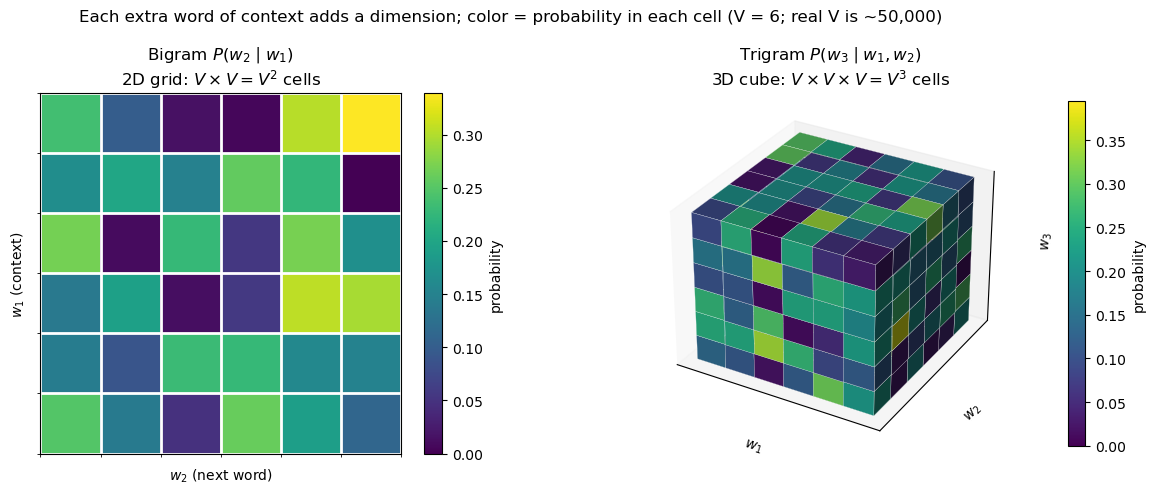

In [1]:
# Curse of dimensionality: each extra word of context adds a dimension.
# Color encodes the probability value stored in each cell.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

n = 6  # small illustrative vocabulary (the real V is ~50,000)
rng = np.random.default_rng(0)

# Toy conditional-probability tables (each conditional distribution sums to 1)
P2 = rng.random((n, n));     P2 /= P2.sum(axis=1, keepdims=True)   # P(w2 | w1)
P3 = rng.random((n, n, n));  P3 /= P3.sum(axis=2, keepdims=True)   # P(w3 | w1, w2)

cmap = "viridis"
fig = plt.figure(figsize=(13, 5))

# --- Left: bigram table = 2D grid, colored by probability ---
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.imshow(P2, cmap=cmap, vmin=0, vmax=P2.max())
ax1.set_xticks(np.arange(-.5, n, 1), minor=True)
ax1.set_yticks(np.arange(-.5, n, 1), minor=True)
ax1.grid(which="minor", color="white", linewidth=2)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_xlabel("$w_2$ (next word)"); ax1.set_ylabel("$w_1$ (context)")
ax1.set_title("Bigram $P(w_2 \\mid w_1)$\n2D grid: $V \\times V = V^2$ cells")
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="probability")

# --- Right: trigram table = 3D cube, voxels colored by probability ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
norm = plt.Normalize(vmin=0, vmax=P3.max())
facecolors = plt.get_cmap(cmap)(norm(P3))
ax2.voxels(np.ones((n, n, n), dtype=bool), facecolors=facecolors,
           edgecolor="white", linewidth=0.2)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
ax2.set_xlabel("$w_1$"); ax2.set_ylabel("$w_2$"); ax2.set_zlabel("$w_3$")
ax2.set_title("Trigram $P(w_3 \\mid w_1, w_2)$\n3D cube: $V \\times V \\times V = V^3$ cells")
sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax2, fraction=0.03, pad=0.1, label="probability")

fig.suptitle(f"Each extra word of context adds a dimension; color = probability in each cell "
             f"(V = {n}; real V is ~50,000)", fontsize=12)
plt.tight_layout()
plt.show()


# How to Estimate Probabilities

**The simplest idea: count and divide**. This is **Maximum Likelihood Estimation (MLE)**:

$$
P(\text{sat} \mid \text{the cat}) = \frac{\text{Count}(\text{the cat sat})}{\text{Count}(\text{the cat})}
$$

It is just **one** estimator (the most basic one), and its weakness follows directly from the curse of dimensionality we just saw:

- There are astronomically many possible contexts, so **most never appear** in any corpus.
- An unseen context gives count 0 → probability 0 → the whole sentence gets probability 0.

Counting alone cannot fill a space this large. The deeper question is: **how do we estimate probabilities for contexts we have never seen?**

In [2]:
import nltk
from nltk.corpus import brown
from collections import Counter

# Download corpus if not already
nltk.download("brown")

# Use the
tokens = brown.words()

# Build bigrams
bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

# Count frequencies
unigram_counts = Counter(tokens)
bigram_counts = Counter(bigrams)

# Example: P(man | the)
num = bigram_counts[("the", "man")]
den = unigram_counts["the"]
prob = num / den if den > 0 else 0

print("P(man | the) =", prob)


[nltk_data] Downloading package brown to
[nltk_data]     /Users/arminmehrabian/nltk_data...
[nltk_data]   Package brown is already up-to-date!


P(man | the) = 0.002041044121633473


# Estimating from a Real Corpus  

We can compute probabilities directly from counts in a large corpus.  

**Example (Brown corpus):**  

$$
P(\text{man} \mid \text{the}) 
= \frac{\text{Count}(\text{the man})}{\text{Count}(\text{the})}
\approx 0.002
$$  

**Observation:**  
Even in a large corpus, many reasonable phrases have **very low probabilities**.  
This highlights the **sparsity problem** in language modeling.


# From Counting to Learning

How do we estimate $P(\text{word} \mid \text{context})$ for contexts we have never seen?

The field's answer evolved:

### Count & divide  →  Smoothing  →  Neural LMs  →  Transformers / LLMs

- **Counting** memorizes exact n-grams, and breaks on unseen ones.
- **Learning** a function (word embeddings + shared parameters) lets the model *generalize* to similar contexts.

Modern LLMs estimate the same $P(\text{next token} \mid \text{context})$, but they **learn** it from data instead of counting. (More in later lectures.)

# What Markov Models Solve

The chain rule is exact, but it asks for the **entire history** to predict each word:

$$
P(w_i \mid w_1, w_2, \ldots, w_{i-1})
$$

As we just saw, those long contexts are almost never observed, so we cannot estimate them reliably.

**The Markov idea:** approximate the full history with only the **last few words**.

$$
P(w_i \mid w_1, \ldots, w_{i-1}) \;\approx\; P(w_i \mid w_{i-k}, \ldots, w_{i-1})
$$

The next slides build this up from the unigram (no context) to the bigram (one word of context).

# The Simplest Case: Unigram Model

**Unigram assumption:** each word is chosen independently of the others.

$$
P(w_1, w_2, \dots, w_n) \;\approx\; \prod_{i=1}^{n} P(w_i)
$$

**Text generated from a unigram model:**
- *dog, is, a, sat, happy, on, mat*
- *house, big, the, tree, runs, cat*

The words are fine individually, but the sequence is nonsensical: a unigram model ignores context entirely.

# Why Unigrams Fail

A unigram model just multiplies independent word probabilities, so word **order does not matter**:

$$
P(\text{the dog}) = P(\text{the})\,P(\text{dog}) = P(\text{dog})\,P(\text{the}) = P(\text{dog the})
$$

It has no preference for "the dog" over "dog the". With no sense of order or grammar, it produces gibberish.

This is why we need at least a **bigram** model, which brings in one word of context.

In [3]:
import random
from collections import Counter, defaultdict
from nltk.corpus import brown

# Use the full Brown corpus
tokens = brown.words()

def build_ngram_model(tokens, order=1):
    """
    Build an n-gram language model of given order.
    
    Parameters:
    - tokens: list of words from the corpus
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    
    Returns:
    - followers: dictionary mapping context → list of next words
    """
    ngrams = [tuple(tokens[i:i+order+1]) for i in range(len(tokens) - order)]
    ngram_counts = Counter(ngrams)

    followers = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context, next_word = ngram[:-1], ngram[-1]
        followers[context].extend([next_word] * count)

    return followers

def generate_sentence(followers, order=1, length=10, start=None):
    """
    Generate a sentence using an n-gram model.
    
    - followers: trained model
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    - length: number of words to generate
    - start: optional start word/tuple. If None, chosen randomly.
    """
    # Pick a valid random start if none provided
    if start is None:
        start = random.choice(list(followers.keys()))
    
    # Ensure start is a tuple
    if not isinstance(start, tuple):
        start = (start,)
    
    # If start length doesn't match order, replace with random context
    if len(start) != order:
        start = random.choice(list(followers.keys()))
    
    # Begin sentence
    sentence = list(start)

    for _ in range(length - len(start)):
        context = tuple(sentence[-order:]) if order > 0 else tuple()
        if context not in followers:
            break
        next_word = random.choice(followers[context])
        sentence.append(next_word)

    return " ".join(sentence)

# -----------------
# Example usage:
# -----------------

# Change order here: 0=unigram, 1=bigram, 2=trigram, etc.
order = 0
model = build_ngram_model(tokens, order=order)

# Generate a sample sentence
print(generate_sentence(model, order=order, length=15))


public in new us And narrow , , Home-made by future peoples is index not


# The Markov Assumption

**First-order Markov assumption:** each word depends only on the **one** word before it.

$$
P(w_i \mid w_1, w_2, \dots, w_{i-1}) \;\approx\; P(w_i \mid w_{i-1})
$$

- A model using this assumption is a **bigram model**.
- The previous word stands in as a summary of the entire history before it.

# Why Make This Assumption?

It is a practical trade-off between accuracy and tractability.

**Gain:** far fewer parameters. A trigram needs $O(V^3) \approx 125$ trillion, while a bigram needs only $O(V^2) \approx 2.5$ billion, so we can actually estimate it from data.

**Loss:** we miss long-distance dependencies, such as the link between "The book ..." and "... was fascinating".

# Bigram Probability and Log Space

**Probability of a sequence under a bigram model:**

$$
P(w_1, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_{i-1})
$$

In practice we compute this in **log space**:

$$
\log P(w_1, \dots, w_n) = \sum_{i=1}^{n} \log P(w_i \mid w_{i-1})
$$

Logs turn a product into a sum, which is faster and avoids numerical problems (next slide).

# Why Logs: The Underflow Problem

Probabilities of long sentences get tiny. For a 10-word sentence with typical bigram probabilities near 0.001:

$$
P(\text{sentence}) \approx 0.001^{10} = 10^{-30}
$$

Floating-point numbers keep about 16 digits of precision, so $10^{-30}$ **underflows to zero** and we lose all information.

In log space there is no underflow:

$$
\log P(\text{sentence}) = 10 \times \log(0.001) = -30
$$

# Special START Token

**Problem:** in a bigram model the first word $w_1$ has no previous word, so $P(w_1 \mid w_0)$ is undefined.

**Solution:** add a special token $w_0 = \langle \text{START} \rangle$ with $P(w_0) = 1$, so every word (including the first) has a context and we keep one uniform formula.

**Example.** For the sentence "the cat sat":

$$
P(\text{the cat sat}) = P(\text{the} \mid \langle \text{START} \rangle)\; P(\text{cat} \mid \text{the})\; P(\text{sat} \mid \text{cat})
$$

The $\langle \text{START} \rangle$ token lets the model score the first word by how often sentences actually begin with it.

# Connection to Modern Special Tokens

The same trick, adding special tokens to mark structure, is everywhere in modern models:

- $\langle \text{BOS} \rangle$ and $\langle \text{EOS} \rangle$: mark the beginning and end of a sequence (the direct descendants of $\langle \text{START} \rangle$).
- $\langle \text{PAD} \rangle$: pad short sequences to a fixed length for batching.
- $\langle \text{MASK} \rangle$: the token BERT learns to predict during pretraining.
- `[CLS]` and `[SEP]`: summarize and separate sentences for classification tasks.

The idea started right here, with these early Markov and n-gram models.

In [9]:
# build_ngram_model() and generate_sentence() were defined above.
# Now raise the Markov order to see how longer context changes generation.

for order in [1, 2, 3]:
    model = build_ngram_model(tokens, order=order)
    print(f"order={order}: {generate_sentence(model, order=order, length=15)}")

order=1: privacy . <END> <START> two carpenters and visible church is really are braced himself .
order=2: a tinplated lighter , both banks and insurance since the man told me , ``
order=3: The American people have indeed come a long way toward bolstering or destroying cosmic theories


# N-gram Models: Limitations  

- We can extend to trigrams, 4-grams, 5-grams, etc.  
- But in general, this is still an **insufficient model of language**  
  - because natural language often has **long-distance dependencies**  


**Example:**  

*"The book that the professor recommended during the seminar was fascinating."*  

- The word *"book"* (subject) connects to *"was fascinating"* (verb + predicate).  
- An N-gram model with only short context may fail to capture this relationship.  


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 2. Language Model Evaluation



# Extrinsic Evaluation of Language Models  

**Best way to compare models A and B:** test them in a **real application**  

- Examples: spelling correction, speech recognition, machine translation, question answering, summarization  
- Run the task, measure accuracy for A and for B  
  - How many misspelled words corrected properly?  
  - How many words translated correctly?  

**A/B testing = extrinsic evaluation with real users**  
- Instead of offline benchmarks, deploy A and B to different user groups  
- Compare real-world metrics (engagement, satisfaction, revenue)  



# Language Model Evaluation (1/2)  

**What makes a good language model (LM)?**  
It assigns high probability to sentences in the test set.  

---

- **Goal:**  
  Estimate $P_{\text{LM}}$ from training data, and then evaluate on **unseen test data $W$**.  

- **Perplexity:**  
  A measure of how "surprised" the model is when it encounters the test data.  

- **Interpretation:**  
  Lower perplexity = better performance.  


# Intrinsic Evaluation of Language Models  

**Definition:**  
Evaluate the model by comparing its predictions directly against held-out test data.  



**Characteristics:**  
- Uses a **standalone metric** (no downstream task).  
- Fast, cheap, easy to compute.  
- Provides a quick **proxy for model quality**.  


**Examples of intrinsic metrics:**  
- **Perplexity** (how well the model predicts sequences).  
- **Log-likelihood** of the held-out data.  

Intrinsic evaluation measures the model's **predictive power** directly, without embedding it into an application.

# Perplexity: How Surprised Is the Model?

Perplexity measures how well a language model predicts a held-out sequence. For $w = (w_1, \dots, w_N)$:

$$
PP(w) = P(w)^{-1/N} = \exp\!\left(-\frac{1}{N}\sum_{i=1}^N \log P(w_i \mid \text{context})\right)
$$

- $N$ is the number of tokens, so this is a per-word average (sentence length does not inflate the score).
- Lower perplexity means the model gave the real text higher probability, so it was less surprised.

# Perplexity as a Branching Factor

Perplexity answers: *on average, how many words is the model effectively choosing from?*

**Anchor example:** a model that is uniform over $k$ equally likely words has perplexity exactly $k$. (A fair 6-sided die has perplexity 6.)

**Predictable context lowers it:**
- "I pledge allegiance to the ___" is almost certainly "flag", so perplexity is near 1 to 2.

**Unpredictable context raises it:**
- "I saw a ___" could be dog, cat, car, tree, and many more, so perplexity is in the hundreds.

# Perplexity in Practice

**Lower is better:** fewer effective choices, less surprise. Perplexity is an **intrinsic** metric, fast to compute with no downstream task needed.

**Typical numbers on English text:**
- Bigram model: about 100 to 200
- Trigram model: about 50 to 100
- Neural LM (LSTM): about 20 to 40
- Large transformer (GPT-3): about 10 to 20

**Caveat:** lower perplexity does not always mean better performance on the actual downstream task.

# Perplexity with a Uniform Distribution

**Setup:**  
- Vocabulary = {zero, one, two, …, nine}  
- Size of vocabulary = 10 words  
- Model $M$ is **uniform**: every word has probability $1/10$  



**Sentence probability:**  
For a sequence $W$ of $N$ words:  

$$
P(W) = \left(\frac{1}{10}\right)^N
$$  



**Perplexity:**  

$$
PP(W) = \left(\frac{1}{P(W)}\right)^{1/N}  
= \left(\frac{1}{(1/10)^N}\right)^{1/N}  
= 10
$$  


  
For a uniform model, perplexity = **vocabulary size** (independent of sentence length).  

# Perplexity with a 1-word context (bigram)

**Corpus:**  
*"the cat sat"*  
*"the cat ran"*  
*"the dog barked"*  


**Step 1: Count frequencies**  
- Count(the) = 3  
- Count(cat) = 2, Count(dog) = 1  
- Count(the, cat) = 2  
- Count(the, dog) = 1  



**Step 2: Estimate conditional probabilities**  

$$
P(\text{cat} \mid \text{the}) = \frac{2}{3} \quad ; \quad
P(\text{dog} \mid \text{the}) = \frac{1}{3}
$$  



**Step 3: Compute perplexity (N=2)**  

For *"the cat"* :  

$$
P(\text{the cat}) = P(\text{the}) \times P(\text{cat} \mid \text{the})
= \frac{3}{6} \times \frac{2}{3} = \frac{1}{3}
$$  

$$
PP = \left(\frac{1}{1/3}\right)^{1/2} = \sqrt{3} \approx 1.73
$$  

For *"the dog"* :  

$$
P(\text{the dog}) = P(\text{the}) \times P(\text{dog} \mid \text{the})
= \frac{3}{6} \times \frac{1}{3} = \frac{1}{6}
$$  

$$
PP = \left(\frac{1}{1/6}\right)^{1/2} = \sqrt{6} \approx 2.45
$$  
  



**Interpretation:**  
- Lower perplexity for *"the cat"* → model is **less surprised**.  
- Higher perplexity for *"the dog"* → model is **more surprised**.

In [5]:
# import math
# from collections import Counter, defaultdict
# from nltk.corpus import brown
# import nltk

# nltk.download("brown")

# --------------------------
# Step 1: Preprocess corpus
# --------------------------

# Use sentence tokenization, add START/END tokens
sents = brown.sents()
tokens = []
for s in sents:
    tokens.extend(["<START>"] + list(s) + ["<END>"])

# --------------------------
# Step 2: Build unigram model
# --------------------------

unigram_counts = Counter(tokens)
total_unigrams = sum(unigram_counts.values())

def unigram_prob(word):
    """Return P(word) under unigram model"""
    return unigram_counts[word] / total_unigrams

# --------------------------
# Step 3: Build bigram model
# --------------------------

bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]
bigram_counts = Counter(bigrams)

# For convenience, also keep unigram counts (already built)
def bigram_prob(w2, w1):
    """Return P(w2 | w1) under bigram model"""
    if unigram_counts[w1] == 0:
        return 0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]

# --------------------------
# Step 4: Sentence probability
# --------------------------

def prob_sentence_unigram(sentence):
    """
    Compute probability of a sentence under unigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for w in words:
        p *= unigram_prob(w)
    return p

def prob_sentence_bigram(sentence):
    """
    Compute probability of a sentence under bigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob(words[i], words[i-1])
    return p

# --------------------------
# Step 5: Perplexity
# --------------------------

def perplexity(prob, N):
    """
    Compute perplexity from sentence probability
    prob: sentence probability
    N: number of words in the sentence (excluding START/END)
    """
    if prob == 0:
        return float("inf")
    return (1/prob) ** (1/N)

# --------------------------
# Example
# --------------------------

sentence = ["the", "cat", "sat"]

p_uni = prob_sentence_unigram(sentence)
p_bi = prob_sentence_bigram(sentence)

print("Unigram probability:", p_uni)
print("Bigram probability:", p_bi)

print("Unigram perplexity:", perplexity(p_uni, len(sentence)))
print("Bigram perplexity:", perplexity(p_bi, len(sentence)))


Unigram probability: 1.9991545513791433e-13
Bigram probability: 0.0
Unigram perplexity: 17102.169640701308
Bigram perplexity: inf


# Data Sparsity: The Zero-Probability Problem

Many valid word pairs never appear in the training data.

- If "cat sat" was never seen, then $P(\text{sat} \mid \text{cat}) = 0$.
- A single zero makes the whole sentence probability 0, and perplexity becomes infinite.

One unseen bigram should not make an entire sentence impossible. We need to reserve some probability for events we have not observed.

# Add-1 (Laplace) Smoothing

Add one to every bigram count, so nothing is exactly zero:

$$
P(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i) + 1}{\text{Count}(w_{i-1}) + V}
$$

where $V$ is the vocabulary size.

- Unseen pairs get a small non-zero probability.
- Frequent pairs give up a little probability mass to pay for it.

The code below applies this to our toy corpus.

In [6]:
# Add-1 smoothing for bigrams

V = len(unigram_counts)  # vocabulary size

def bigram_prob_smoothed(w2, w1):
    """
    Add-1 smoothed bigram probability:
    P(w2 | w1) = (Count(w1, w2) + 1) / (Count(w1) + V)
    """
    return (bigram_counts[(w1, w2)] + 1) / (unigram_counts[w1] + V)

def prob_sentence_bigram_smoothed(sentence):
    """
    Probability of a sentence with Add-1 smoothing.
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob_smoothed(words[i], words[i-1])
    return p

# Example: "the cat sat"
sentence = ["the", "cat", "sat"]
p_bi_smoothed = prob_sentence_bigram_smoothed(sentence)
pp_bi_smoothed = perplexity(p_bi_smoothed, len(sentence))

print("Smoothed bigram probability:", p_bi_smoothed)
print("Smoothed bigram perplexity:", pp_bi_smoothed)


Smoothed bigram probability: 5.177147186418028e-17
Smoothed bigram perplexity: 268309.7755374276


# Intuition of Perplexity (1/2)  

**The Shannon Game:**  
How well can a model predict the next word?  

Examples:  
- *I always order pizza with cheese and …*  
- *The 33rd President of the US was …*  
- *I saw a …*  


# Intuition of Perplexity (2/2)  

- **Unigram models** fail → they only use word frequency.  
- A **better model** assigns higher probability to the correct word.  

**Connection to perplexity:**  
- Perplexity measures how “surprised” the model is.  
- Lower perplexity = better predictions (fewer average choices).  


# N-gram Length and Performance  

### Does increasing N-gram length always improve language models?  

**Yes, but only up to a point.**  

- Longer context → more accurate conditional probabilities  
- But **data sparsity** grows quickly:  
  - Unigram: $O(V)$ parameters  
  - Bigram: $O(V^2)$ parameters  
  - Trigram: $O(V^3)$ parameters  
- Most higher-order n-grams will have **zero counts** in real data  

**Trade-off:**  
- Larger $N$ captures longer dependencies  
- But requires far more data to estimate reliably


### N-gram Tools and Resources

Popular toolkits for building and querying large N-gram models:

- **KenLM**: a fast, memory-efficient N-gram LM library. https://kheafield.com/code/kenlm/
- **SRILM**: a classic statistical language-modeling toolkit. http://www.speech.sri.com/projects/srilm/

**Historical note: the Google N-gram release (2006).** Google published a massive N-gram dataset ("All Our N-gram Are Belong to You"):
- Counts for 1-grams through 5-grams from a large web corpus
- Over 1 trillion tokens and about 13 million unique words
- A foundational resource for early statistical NLP

<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 3. Hidden Markov Models



# Hidden Markov Models

### Why do we need them?

Many NLP tasks involve **sequences where the labels we care about are hidden** and must be inferred from what we observe:

| Task | Observed | Hidden (to infer) |
|------|----------|-------------------|
| **POS tagging** | words ("the", "dog", "barked") | tags (DET, NOUN, VERB) |
| **Speech recognition** | audio waveform | words / phonemes |
| **Named entity recognition** | word tokens | entity labels (PERSON, ORG, LOC) |

A **Hidden Markov Model (HMM)** is a simple probabilistic model for exactly this: a chain of hidden states we cannot see directly, each one generating an observation we can.

**Why study them?** HMMs are simple enough to understand fully, yet they introduce ideas (hidden state, transitions, and decoding a best sequence) that reappear in the neural sequence models (RNNs, Transformers) we cover later.

# Noisy Channel Models

**Key idea:**  
- Messages pass through a noisy channel.  
- The receiver must **decode** the original message $T$ from the observed signal $W$.  

<p align="center">
  <img src="img/noisy_channel.png" alt="Noisy Channel Model" width="900"/>
</p>

- $P(T)$ → Prior probability of the original message  
- $P(W \mid T)$ → Probability of the noisy version given $T$  
- Decoder: chooses $\hat{T} = \arg\max_T P(T) \cdot P(W \mid T)$  


**Example (spelling correction):**  
Observed $W =$ "hte"  
- Candidate $T =$ "the"  
  - $P(T)$: "the" is very common in English  
  - $P(W \mid T)$: "hte" is a likely typo for "the"  
- Candidate $T =$ "hat"  
  - $P(T)$: also common, but  
  - $P(W \mid T)$: "hte" is an unlikely typo for "hat"  

Decoder picks **"the"** since it maximizes $P(T)\cdot P(W \mid T)$  


# Hidden vs. Observed in POS Tagging  

- **Observed ($W$):** sentence words (e.g., "the dog barked")  
- **Hidden ($T$):** part-of-speech tags (DET, NOUN, VERB)  

How it works:  
- Hidden POS tags follow a sequence model (transitions)  
- Each tag generates words with certain probabilities (emissions)  

Goal: recover the hidden tag sequence $T$  
that best explains the observed words $W$.  


# From Noisy Channel to HMMs  

We model the joint distribution as:  

$$
P(T, W) = \prod_i P(t_i \mid t_{i-1}) \; P(w_i \mid t_i)
$$  

**Why can we do this?**  
Because HMMs make two simplifying assumptions:  

1. **Markov assumption (states):**  
   Each hidden state $t_i$ depends only on the previous state $t_{i-1}$.  
   (*No long-distance dependencies among hidden states.*)  

2. **Emission assumption (observations):**  
   Each observed word $w_i$ depends only on its current hidden state $t_i$.  
   (*No direct dependence on other hidden states or observations.*)  

Together, these assumptions let us factorize the joint distribution into  
**transition probabilities × emission probabilities.**  

This decomposition = the core idea of a Hidden Markov Model.  


# Transitions and Emissions

The HMM factorization $P(T,W)=\prod_i P(t_i\mid t_{i-1})\,P(w_i\mid t_i)$ uses two kinds of probabilities:

**Transition** $P(t_i \mid t_{i-1})$: how likely one hidden state follows another.
- POS example: $P(\text{Noun}\mid\text{DET})$ is high; $P(\text{Verb}\mid\text{DET})$ is low.
- Captures **syntax**: which tag tends to follow which.

**Emission** $P(w_i \mid t_i)$: how likely a hidden state produces an observed word.
- POS example: a Noun often emits "dog"/"cat"; a Verb often emits "barked"/"ran".
- Captures **vocabulary**: which words a tag tends to produce.

Plus a **start distribution** $\pi = P(t_1)$ for the first state. Those three pieces $(A, B, \pi)$ are the whole model.

# A Small HMM Example

A toy HMM for tagging short sentences with three tags (DET, NOUN, VERB).

**Transition probabilities $A$**, $P(\text{next} \mid \text{current})$, each row sums to 1:

| from \ to | DET | NOUN | VERB | END |
|-----------|-----|------|------|-----|
| **START** | 0.8 | 0.2  | 0.0  | 0.0 |
| **DET**   | 0.1 | 0.9  | 0.0  | 0.0 |
| **NOUN**  | 0.0 | 0.1  | 0.6  | 0.3 |
| **VERB**  | 0.0 | 0.2  | 0.1  | 0.7 |

**Emission probabilities $B$**, $P(\text{word} \mid \text{tag})$, each row sums to 1:

| tag \ word | the | dog | barked |
|------------|-----|-----|--------|
| **DET**    | 0.9 | 0.0 | 0.0    |
| **NOUN**   | 0.1 | 0.7 | 0.2    |
| **VERB**   | 0.0 | 0.1 | 0.9    |

The tags form a hidden chain; each tag emits one observed word:

```
START -> DET --> NOUN --> VERB -> END
          |        |         |
        "the"    "dog"    "barked"
```

# Scoring a Tag Sequence

How likely is the tagging **DET NOUN VERB** for the words **"the dog barked"**? Walk the chain, multiplying each transition by the emission at that step:

| step | transition | emission |
|------|-----------|----------|
| START → DET | 0.8 | the: 0.9 |
| DET → NOUN  | 0.9 | dog: 0.7 |
| NOUN → VERB | 0.6 | barked: 0.9 |
| VERB → END  | 0.7 | (none) |

$$
P(\text{DET NOUN VERB},\ \text{the dog barked}) = 0.8 \times 0.9 \times 0.9 \times 0.7 \times 0.6 \times 0.9 \times 0.7 \approx 0.171
$$

Now compare a wrong tagging, **NOUN NOUN VERB**:

$$
= 0.2 \times 0.1 \times 0.1 \times 0.7 \times 0.6 \times 0.9 \times 0.7 \approx 0.0005
$$

DET NOUN VERB scores far higher, so it is the better explanation of the sentence. The **Viterbi** algorithm finds this best-scoring sequence efficiently, without enumerating every possibility.

# Inference: Finding the Hidden Sequence

Given the observed words, we usually want the **most likely hidden sequence** (e.g., the best tag sequence for a sentence).

- Trying every possible sequence is **exponential**: $N$ states over $T$ words gives $N^T$ paths (e.g., 12 tags, 20 words is about $4\times10^{21}$).
- The **Viterbi algorithm** finds the best path efficiently with **dynamic programming**, in $O(N^2 T)$ time, by keeping only the best way to reach each state at each step.

We won't derive Viterbi here, but the key point is that the Markov assumption makes exact decoding tractable. The same dynamic-programming idea reappears in parsing and in beam search for neural models.

# Summary and What's Next

**Today:**
- **Language models** assign probabilities to word sequences; the **chain rule** plus the **Markov (n-gram) assumption** make this tractable.
- We **evaluate** language models with **perplexity** (lower is better, the model's average branching factor), and handle unseen n-grams with **smoothing**.
- **Hidden Markov Models** extend these ideas to sequences with **hidden** labels (POS tags, etc.), combining **transition** and **emission** probabilities, with **Viterbi** for decoding.

**Next:** these probabilistic sequence models are the foundation for **neural sequence models** (RNNs, LSTMs, and Transformers) that learn richer, longer-range context directly from data.